In [1]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter


In [2]:
# Cell 2 — Version 1: Node + Tree class (minimal)
def gini(y):
    counts = np.bincount(y.astype(int))
    probs  = counts / len(y)
    return 1 - np.sum(probs**2)

def best_split(X, y):
    best_ig, best_feat, best_thresh = -1, None, None
    parent_gini = gini(y)
    n_features  = X.shape[1]

    for feat in range(n_features):
        thresholds = np.unique(X[:, feat])
        for thresh in thresholds:
            left  = y[X[:, feat] < thresh]
            right = y[X[:, feat] >= thresh]
            if len(left)==0 or len(right)==0:
                continue
            weighted = (len(left)*gini(left) + len(right)*gini(right)) / len(y)
            ig = parent_gini - weighted
            if ig > best_ig:
                best_ig, best_feat, best_thresh = ig, feat, thresh

    return best_feat, best_thresh

class Node:
    def __init__(self, feature=None, threshold=None, left=None, right=None, value=None):
        self.feature   = feature
        self.threshold = threshold
        self.left      = left
        self.right     = right
        self.value     = value   # leaf node class

class DecisionTreeScratch:
    def __init__(self, max_depth=5):
        self.max_depth = max_depth
        self.root      = None

    def _build(self, X, y, depth=0):
        if depth >= self.max_depth or len(np.unique(y)) == 1:
            return Node(value=Counter(y).most_common(1)[0][0])
        feat, thresh = best_split(X, y)
        if feat is None:
            return Node(value=Counter(y).most_common(1)[0][0])
        left_mask = X[:, feat] < thresh
        left  = self._build(X[left_mask],  y[left_mask],  depth+1)
        right = self._build(X[~left_mask], y[~left_mask], depth+1)
        return Node(feature=feat, threshold=thresh, left=left, right=right)

    def fit(self, X, y):
        self.root = self._build(X, y)

    def _predict_one(self, x, node):
        if node.value is not None:
            return node.value
        if x[node.feature] < node.threshold:
            return self._predict_one(x, node.left)
        return self._predict_one(x, node.right)

    def predict(self, X):
        return np.array([self._predict_one(x, self.root) for x in X])

print("DecisionTreeScratch class defined ✅")

DecisionTreeScratch class defined ✅


Training accuracy: 92.5%


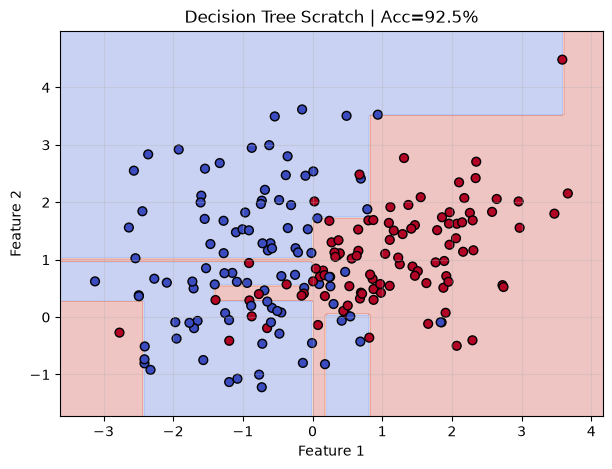

In [3]:
# Cell 3 — Version 2: train on pass/fail dataset
from sklearn.datasets import make_classification

np.random.seed(42)
X, y = make_classification(n_samples=200, n_features=2, n_redundant=0,
                            n_informative=2, random_state=42, n_clusters_per_class=1)

tree = DecisionTreeScratch(max_depth=4)
tree.fit(X, y)
preds = tree.predict(X)
acc   = np.mean(preds == y)
print(f"Training accuracy: {acc*100:.1f}%")

# plot decision boundary
x_min, x_max = X[:,0].min()-0.5, X[:,0].max()+0.5
y_min, y_max = X[:,1].min()-0.5, X[:,1].max()+0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))
Z = tree.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.figure(figsize=(7, 5))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
plt.scatter(X[:,0], X[:,1], c=y, cmap='coolwarm', edgecolors='k', s=40)
plt.title(f'Decision Tree Scratch | Acc={acc*100:.1f}%')
plt.xlabel('Feature 1'); plt.ylabel('Feature 2')
plt.grid(True, alpha=0.3); plt.show()

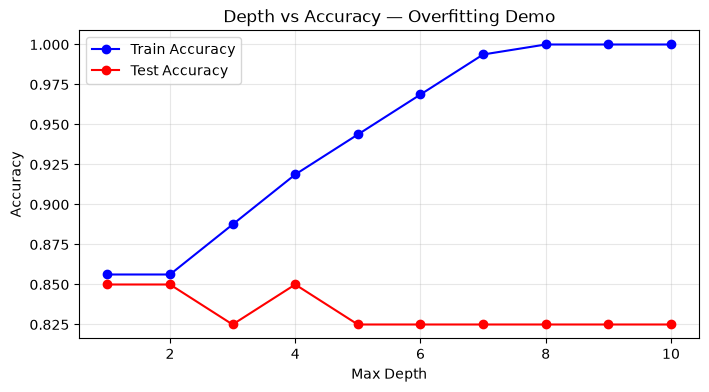

High depth = overfit: train acc high, test acc drops ✅


In [4]:
# Cell 4 — Version 3: depth vs accuracy (overfitting demo)
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

train_accs, test_accs = [], []
depths = range(1, 11)

for d in depths:
    t = DecisionTreeScratch(max_depth=d)
    t.fit(X_train, y_train)
    train_accs.append(np.mean(t.predict(X_train) == y_train))
    test_accs.append(np.mean(t.predict(X_test)  == y_test))

plt.figure(figsize=(8, 4))
plt.plot(depths, train_accs, 'b-o', label='Train Accuracy')
plt.plot(depths, test_accs,  'r-o', label='Test Accuracy')
plt.xlabel('Max Depth'); plt.ylabel('Accuracy')
plt.title('Depth vs Accuracy — Overfitting Demo')
plt.legend(); plt.grid(True, alpha=0.3); plt.show()
print("High depth = overfit: train acc high, test acc drops ✅")

Fruit classifier accuracy: 86.7%


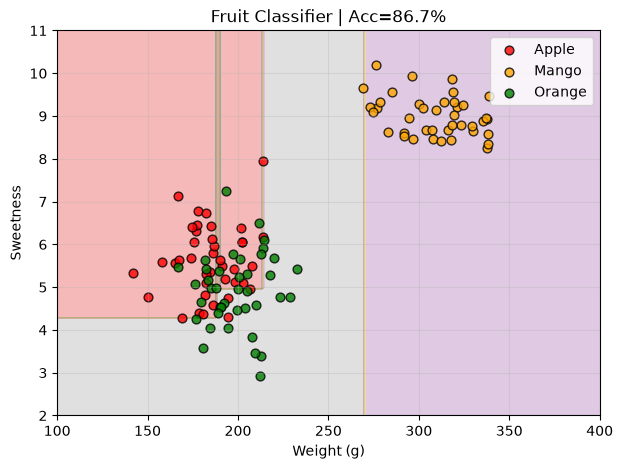

In [5]:
# Cell 5 — Version 4: fruit classification (intuitive example)
# Features: [weight(g), sweetness(1-10)]  Label: 0=apple, 1=mango, 2=orange
np.random.seed(0)
apples  = np.column_stack([np.random.normal(180, 15, 40),
                            np.random.normal(6,   1,  40)])
mangoes = np.column_stack([np.random.normal(300, 20, 40),
                            np.random.normal(9,   0.5, 40)])
oranges = np.column_stack([np.random.normal(200, 15, 40),
                            np.random.normal(5,   1,  40)])

X_fruit = np.vstack([apples, mangoes, oranges])
y_fruit = np.array([0]*40 + [1]*40 + [2]*40)

tree_fruit = DecisionTreeScratch(max_depth=5)
tree_fruit.fit(X_fruit, y_fruit)
acc = np.mean(tree_fruit.predict(X_fruit) == y_fruit)
print(f"Fruit classifier accuracy: {acc*100:.1f}%")

xx, yy = np.meshgrid(np.linspace(100, 400, 200),
                     np.linspace(2,   11,  200))
Z = tree_fruit.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.figure(figsize=(7, 5))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='Set1')
colors = ['red','orange','green']
labels = ['Apple','Mango','Orange']
for cls, col, lbl in zip([0,1,2], colors, labels):
    mask = y_fruit == cls
    plt.scatter(X_fruit[mask,0], X_fruit[mask,1],
                c=col, label=lbl, edgecolors='k', s=40, alpha=0.8)
plt.xlabel('Weight (g)'); plt.ylabel('Sweetness')
plt.title(f'Fruit Classifier | Acc={acc*100:.1f}%')
plt.legend(); plt.grid(True, alpha=0.3); plt.show()